<a href="https://colab.research.google.com/github/Zahraghasemzadeh/rPPG/blob/main/plot_rppg_sig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import os
from google.colab import drive
import matplotlib.pyplot as plt
import gdown
import zipfile
import shutil

In [5]:
DATA_PATH = "/content/data"
ZIP_PATH = "/content/ppg_arrhythmia.zip"
FILE_ID = "16jlBsawf1rOefEaxpSbd_dPspnrZS2nB"

In [6]:
if os.path.exists(DATA_PATH):
    print(f"🧹 Removing existing '{DATA_PATH}' folder...")
    shutil.rmtree(DATA_PATH)

# 2. Download
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB
From (redirected): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB&confirm=t&uuid=22f68e8a-59da-4901-b942-f85ff29c50f5
To: /content/ppg_arrhythmia.zip
100%|██████████| 353M/353M [00:08<00:00, 41.5MB/s]


'/content/ppg_arrhythmia.zip'

In [7]:
# 3. Extract
print(f"\n📂 Extracting dataset...")
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/") # Extract to the parent directory
except zipfile.BadZipFile:
    print(f"❌ Error: Failed to open zip file. Download may have been corrupted.")
    # Stop execution if zip is bad
    raise

# 4. Clean up Zip
print("\n🧹 Deleting zip file...")
os.remove(ZIP_PATH)

# 5. Verify
if os.path.exists(DATA_PATH):
    print(f"\n✅ Success! Dataset is ready in the '{DATA_PATH}' folder.")

    print(f"\n📁 Contents of '{DATA_PATH}' :")
    try:
        # List only the first 5 items
        contents = os.listdir(DATA_PATH)
        print(f"  {contents[:5]} {'...' if len(contents) > 5 else ''}")
    except Exception as e:
        print(f"  Could not list contents: {e}")
else:
    print(f"❌ Error: Final directory '{DATA_PATH}' not found after extraction.")
    print("   Please check the zip file's internal structure.")


📂 Extracting dataset...

🧹 Deleting zip file...

✅ Success! Dataset is ready in the '/content/data' folder.

📁 Contents of '/content/data' :
  ['train', 'README.md', 'test'] 


In [8]:
rppg_data = np.load("/content/rppg_20251108-114228.npy", allow_pickle=True)
print(rppg_data.shape)

(768,)


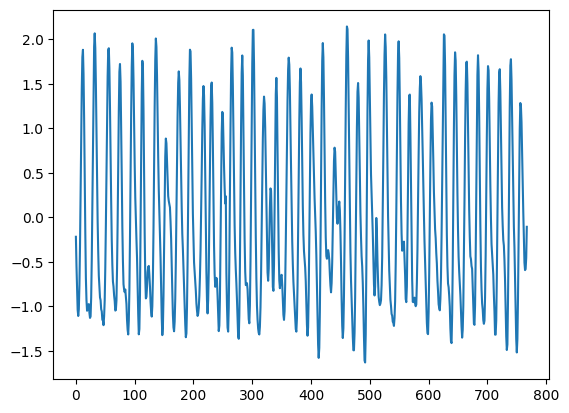

In [9]:
plt.plot(rppg_data)

In [30]:
import pandas as pd
result = pd.read_csv("/content/results.csv")
print(result['data'].head(10))


0     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
1     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
2     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
3     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
4     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
5     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
6     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
7     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
8     b'{"advanced":{"rppg":[],"rppg_timestamps":[]}}'
9    b'{"advanced":{"rppg":[-0.21824229844014462,-0...
Name: data, dtype: object


In [31]:
print(rppg_data[:1])

[-0.2182423]


In [44]:
print(len(result))
print(type(result.data))

31
<class 'pandas.core.series.Series'>


In [48]:
row_str = result.loc[9, "data"]
print(row_str)

b'{"advanced":{"rppg":[-0.21824229844014462,-0.5454415449271547,-0.8082400855973589,-1.0389426601924616,-1.107516590094082,-1.0327855702274853,-0.7601450605597722,-0.3244005932778757,0.2559875923301589,0.8741305276841641,1.4448672718393971,1.7993153751731332,1.8811683134561397,1.607808287934283,1.109208617530857,0.42674878625761414,-0.17118675287467916,-0.6831718095352289,-0.9302569217565865,-1.0488386409831443,-0.9979328888693534,-0.9803081655628979,-0.9743975256005682,-1.0719323521596285,-1.1294493042883007,-1.1122512286887354,-0.8983240371060606,-0.4716752917318381,0.14648799666190668,0.8355572156119979,1.4870734415675475,1.9172554506823667,2.0659535839655727,1.9000360023011669,1.497094482011082,0.9629929883211759,0.4331308191114188,-0.04923219820779459,-0.3926044059220883,-0.655435277907525,-0.770602647243893,-0.899623447468789,-0.9305506955833639,-1.0308719090200662,-1.056313127092855,-1.1502978304069886,-1.1585215782381375,-1.2108800636819876,-1.1118243355927702,-0.93324705809026

900 images @ 30 fps → video length

Duration = 900 frames ÷ 30 fps = 30 seconds